In [6]:
import packages
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D,MaxPooling2D
from keras import backend as K 
(x_train,y_train),(x_test,y_test) =mnist.load_data()
print(x_train.shape,y_train.shape)
x_train=x_train.reshape(x_train.shape[0],28,28,1)
x_test=x_test.reshape(x_test.shape[0],28,28,1) 
input_shape=(28,28,1) 
num_classes=10
y_train=tf.keras.utils.to_categorical(y_train,num_classes=num_classes)
y_test=tf.keras.utils.to_categorical(y_test,num_classes=num_classes)
x_train=x_train.astype("float32") 
x_test=x_test.astype("float32")
x_train/=255
x_test/=255 
batch_size=128
epochs=20
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape))
model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(128,activation='relu')) 
model.add(Dropout(0.5))
model.add(Dense(num_classes,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
hist=model.fit(x_train,y_train,batch_size=batch_size,epochs=epochs,verbose=1, validation_data=(x_test,y_test))
print("The model has successfully trained") 
score=model.evaluate(x_test,y_test,verbose=0)
print('Testloss:',score[0])
print('Test accuracy:',score[1])
model.save('digit.h5')
print("Saving the model as digit.h5")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 33s 3us/step
(60000, 28, 28) (60000,)


C:\Users\Mothilal Chowdary\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 177ms/step - accuracy: 0.7634 - loss: 0.6876 - val_accuracy: 0.9860 - val_loss: 0.0403
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.9772 - loss: 0.0802 - val_accuracy: 0.9892 - val_loss: 0.0317
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.9856 - loss: 0.0517 - val_accuracy: 0.9936 - val_loss: 0.0202
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.9869 - loss: 0.0432 - val_accuracy: 0.9919 - val_loss: 0.0228
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 176ms/step - accuracy: 0.9902 - loss: 0.0353 - val_accuracy: 0.9929 - val_loss: 0.0216
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 176ms/step - accuracy: 0.9914 - loss: 0.0282 - val_accuracy: 0.9945 - val_loss: 0.0182
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1638s 3s/step - accuracy: 0.9912 - loss: 0.0283 - val_accuracy: 0.9931 - val_loss: 0.0260
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 178ms/step - accuracy: 0.9933 - loss: 0.

Testloss: 0.028033150359988213
Test accuracy: 0.9927999973297119
Saving the model as digit.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


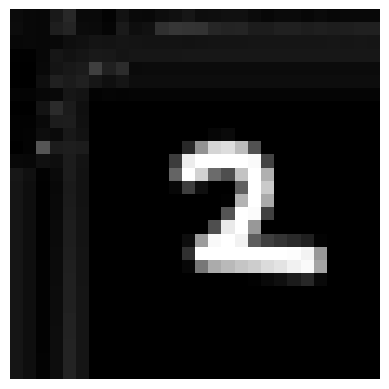

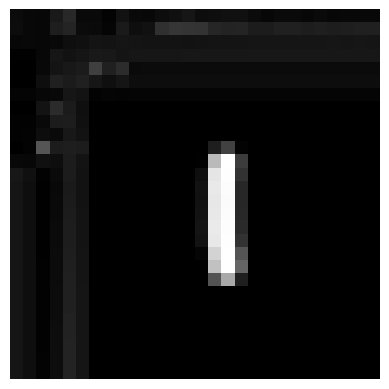

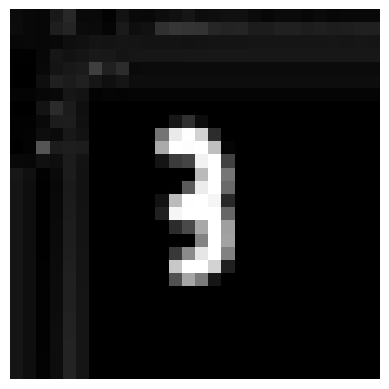

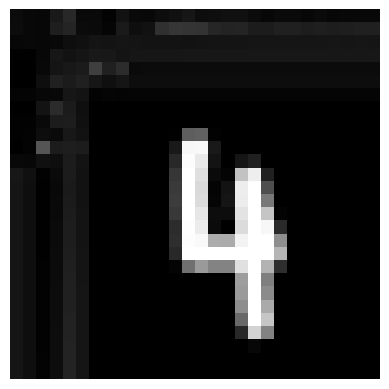

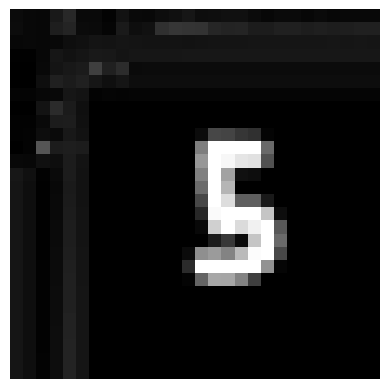

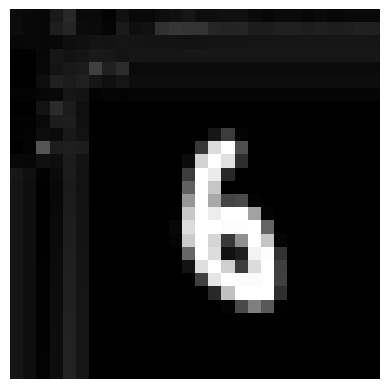

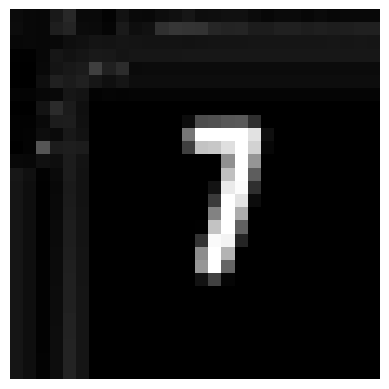

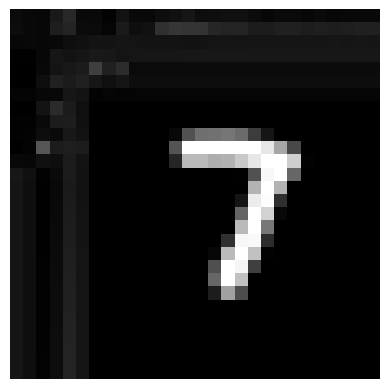

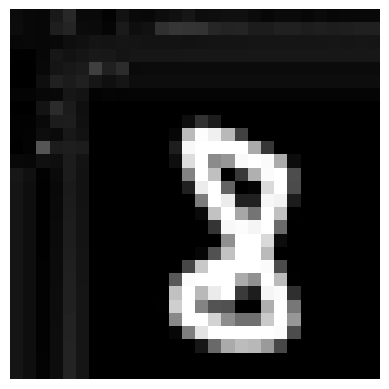

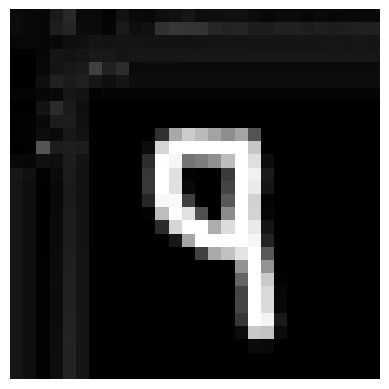

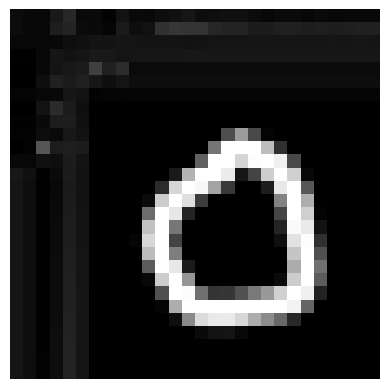

In [15]:
from keras.models import load_model
from tkinter import * 
import tkinter as tk 
import win32gui 
from PIL import ImageGrab,Image
from PIL import ImageOps
import numpy as np
model=load_model('digit.h5') 
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
import matplotlib.pyplot as plt
def preprocess_image(img):
    img=img.convert('L')
    img=ImageOps.invert(img)
    img=img.resize((28,28))
    img_array=np.array(img)
    img_array=img_array.reshape(1,28,28,1)
    img_array=img_array/255.0
    return img_array
def predict_digit(img):
    img_processed=preprocess_image(img)
    plt.figure()
    plt.imshow(img_processed.squeeze(),cmap='gray')
    plt.axis('off')
    res=model.predict(img_processed)[0]
    return np.argmax(res),max(res)
class App(tk.Tk):
    def __init__(self): 
        tk.Tk.__init__(self) 
        self.x=self.y=0 
        self.canvas=tk.Canvas(self,width=300,bg="white",cursor="cross") 
        self.label=tk.Label(self,text="Draw..",font=("Helvetica",48))
        self.classify_btn=tk.Button(self,text="Recognise",command =self.classify_handwriting) 
        self.button_clear=tk.Button(self,text="Clear",command=self.clear_all)
        self.canvas.grid(row=0, column=0, pady=2, sticky=W)
        self.label.grid(row=0, column=1, pady=2,padx=2)
        self.classify_btn.grid(row=1, column=1, pady=2, padx=2)
        self.button_clear.grid(row=1,column=0,pady=2)
        self.canvas.bind("<B1-Motion>",self.paint)
        self.canvas.bind("<ButtonRelease-1>",self.reset)
    def paint(self,event):
        x1,y1=(event.x-10),(event.y-10)
        x2,y2=(event.x+10),(event.y+10)
        self.canvas.create_oval(x1,y1,x2,y2,fill="black",width=5)
    def reset(self,event):
        self.x=self.y=0
    def classify_handwriting(self): 
        HWND=self.canvas.winfo_id()
        rect=win32gui.GetWindowRect(HWND)
        x,y,w,h=rect
        padding=50
        rect=(x-padding,y-padding,x+w+padding,y+h+padding)
        im=ImageGrab.grab(rect)
        digit,acc=predict_digit(im)
        self.label.configure(text="Prediction:"+str(digit)+",Accuracy:"+str(round(acc*100,2))+"%")
    def clear_all(self):
        self.canvas.delete("all")
        self.label.configure(text="Draw..")
app=App()
app.mainloop()
    